In [1]:
from generate_setup_files import *
from pathlib import Path

In [2]:
def _dbg(tag: str, msg: str, value=None):
    """Debug printer (always flushes so output is visible even mid-crash)."""
    sep = "-" * 60
    if value is not None:
        print(f"\n{sep}\n[DBG] [{tag}] {msg}\n      >> {value}\n{sep}", flush=True)
    else:
        print(f"\n{sep}\n[DBG] [{tag}] {msg}\n{sep}", flush=True)

In [5]:
# =========================================================================
    # HARDCODED CONFIGURATION (Change these to test)
    # =========================================================================



for subject in range(1,66):
    for trial in range(1,6):  # List of subject numbers (e.g., "01", "02", "03")
        SUBJECT_NUM = f"{subject:02d}"
        TEMPLATE_JSON_PATH = Path(r"D:\student\MTech\opensim_pipeline_batch_processing\pipeline\template_map.json")  # Path to template.json
        TRIAL_NAME = f"stw{trial}"  # Trial name (e.g., "scale", "stw1", "stw2") — use "scale" for scale setup
        LOG_LEVEL = "DEBUG"
    
        # Root directory (will be read from template if available)
        ROOT_DIR = Path(r"d:\student\MTech\opensim_pipeline_batch_processing")
        
        # =========================================================================
        # End of configuration — no changes needed below
        # =========================================================================
        
        sep = "=" * 70
        print(f"\n{sep}")
        print("[STANDALONE] generate_setup_files.py — Independent Execution")
        print(f"{sep}")
        print(f"  Subject Number      : {SUBJECT_NUM}")
        print(f"  Template JSON       : {TEMPLATE_JSON_PATH}")
        print(f"  Trial Name          : {TRIAL_NAME}")
        print(f"  Root Directory      : {ROOT_DIR}")
        print(f"  Log Level           : {LOG_LEVEL}")
        print(f"{sep}\n")
        
        # Setup logger
        logger = setup_logger(level_name=LOG_LEVEL)
        
        try:
            # =====================================================================
            # Load and adapt template
            # =====================================================================
            print("[STANDALONE] Loading and adapting template...")
            adapted_template = load_and_adapt_template(TEMPLATE_JSON_PATH, SUBJECT_NUM, logger)
            
            # Get root_dir from template if not set
            template_root_dir = adapted_template.get("root_dir", "")
            if template_root_dir:
                ROOT_DIR = Path(template_root_dir)
                _dbg("MAIN", "Using root_dir from template", ROOT_DIR)
            
            # =====================================================================
            # Resolve subject directory
            # =====================================================================
            subj_dir = ROOT_DIR / f"S{SUBJECT_NUM}"
            _dbg("MAIN", "Subject directory", subj_dir)
            _dbg("MAIN", "Subject directory exists?", subj_dir.exists())
            
            if not subj_dir.exists():
                logger.error("Subject directory not found: %s", subj_dir)
                print(f"\n[STANDALONE] ERROR: Subject directory not found!")
                sys.exit(1)
            
            # =====================================================================
            # Resolve model file
            # =====================================================================
            model_file = adapted_template.get("model", "")
            _dbg("MAIN", "Model file path", model_file)
            _dbg("MAIN", "Model file exists?", Path(model_file).exists() if model_file else "no path")
            
            if not model_file:
                logger.error("Model file not found in template")
                print(f"\n[STANDALONE] ERROR: Model file not specified in template!")
                sys.exit(1)
            
            # =====================================================================
            # Resolve trial and setup
            # =====================================================================
            trial = {}
            xml_path = ""
            
            if TRIAL_NAME.lower() == "scale":
                print("[STANDALONE] Processing SCALE setup...")
                xml_path = adapted_template.get("scale_xml", "")
                _dbg("MAIN", "Scale XML path", xml_path)
                
                success = generate_setups_if_needed(
                    subject_num=SUBJECT_NUM,
                    subj_dir=subj_dir,
                    trial={},
                    model_file=model_file,
                    xml=xml_path,
                    trial_name="scale",
                    logger=logger,
                )
            else:
                print(f"[STANDALONE] Processing trial: {TRIAL_NAME}...")
                
                # Find the trial in the adapted template
                trial = get_trial_by_name(adapted_template, TRIAL_NAME, logger)
                
                if trial is None:
                    logger.error("Trial %s not found in template", TRIAL_NAME)
                    print(f"\n[STANDALONE] ERROR: Trial '{TRIAL_NAME}' not found in template!")
                    print(f"[STANDALONE] Available trials:")
                    mapped_trials = adapted_template.get("mapped_trials", [])
                    for t in mapped_trials:
                        trc = t.get("trial_trc", "")
                        trial_stem = Path(trc).stem
                        print(f"              - {trial_stem}")
                    sys.exit(1)
                
                _dbg("MAIN", "Trial data found", f"keys: {list(trial.keys())}")
                
                # Get model file (might be scaled if available)
                model_for_trial = adapted_template.get("model", "")
                _dbg("MAIN", "Model for trial", model_for_trial)
                
                success = generate_setups_if_needed(
                    subject_num=SUBJECT_NUM,
                    subj_dir=subj_dir,
                    trial=trial,
                    model_file=model_for_trial,
                    xml="",
                    trial_name=TRIAL_NAME,
                    logger=logger,
                )
            
            # =====================================================================
            # Result
            # =====================================================================
            print(f"\n{sep}")
            if success:
                print("[STANDALONE] ✓ Setup generation completed successfully")
                print(f"{sep}\n")
            else:
                print("[STANDALONE] ✗ Setup generation completed with errors")
                print(f"{sep}\n")
        
        except Exception as exc:
            print(f"\n[STANDALONE] UNHANDLED EXCEPTION:")
            import traceback
            traceback.print_exc()
            print(f"\n{sep}\n")



[STANDALONE] generate_setup_files.py — Independent Execution
  Subject Number      : 01
  Template JSON       : D:\student\MTech\opensim_pipeline_batch_processing\pipeline\template_map.json
  Trial Name          : stw1
  Root Directory      : d:\student\MTech\opensim_pipeline_batch_processing
  Log Level           : DEBUG

[STANDALONE] Loading and adapting template...

------------------------------------------------------------
[DBG] [TEMPLATE] Loading template from
      >> D:\student\MTech\opensim_pipeline_batch_processing\pipeline\template_map.json
------------------------------------------------------------

------------------------------------------------------------
[DBG] [TEMPLATE] Template loaded — keys
      >> ['subject', 'root_dir', 'model', 'static_trc', 'scale_xml', 'mapped_trials']
------------------------------------------------------------

------------------------------------------------------------
[DBG] [TEMPLATE] Template adapted for subject
      >> 01
----------

In [1]:
import pandas as pd
dataframe = pd.read_csv(r"D:\student\MTech\opensim_pipeline_batch_processing\Subject Details.csv")

array([[<Axes: title={'center': 'Age (Years)'}>,
        <Axes: title={'center': 'Weight (kg)'}>],
       [<Axes: title={'center': 'Height (m)'}>, <Axes: >]], dtype=object)

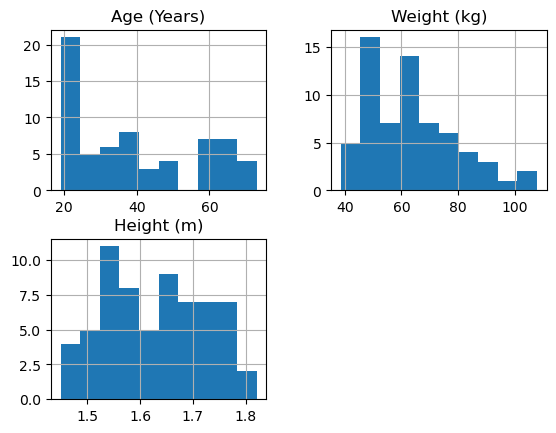

In [5]:
dataframe.hist()

In [6]:
import matplotlib.pyplot as plt

In [8]:
dataframe.head()

,Subject Number,Sex,Age (Years),Weight (kg),Height (m),Dominant Foot
0,S01,M,21,64.50,1.72,Right
1,S02,M,23,62.95,1.71,Right
2,S03,F,19,41.90,1.45,Right
3,S04,M,22,102.45,1.70,Right
4,S05,F,21,52.65,1.55,Right


(array([21.,  5.,  6.,  8.,  3.,  4.,  0.,  7.,  7.,  4.]),
 array([19. , 24.4, 29.8, 35.2, 40.6, 46. , 51.4, 56.8, 62.2, 67.6, 73. ]),
 <BarContainer object of 10 artists>)

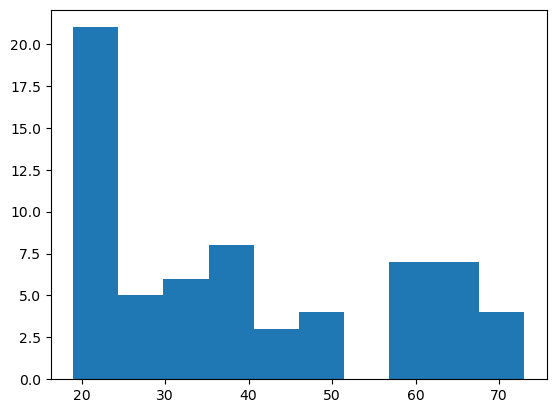

In [12]:
plt.hist(dataframe["Age (Years)"])